In [18]:
# ============================================================
# 01. 导入今天需要使用的Python库
# ============================================================

# os：
# Python自带的文件/文件夹操作工具
# 后面我们会使用它寻找图像文件、构造路径
import os

# glob：
# 用来批量搜索符合某种规则的文件
#
# 例如：
# *.png
# 表示“找到当前文件夹里所有png图片”
import glob

# NumPy：
# 用来处理图像背后的数字矩阵
import numpy as np

# OpenCV：
# 用来读取和处理医学图像
import cv2

# Matplotlib：
# 用来显示图像和保存结果图
import matplotlib.pyplot as plt

import pandas as pd

In [2]:
# ============================================================
# 02. 设置数据集路径
# ============================================================

# ".." 表示：
# 当前notebook在 notebooks/ 文件夹，
# 先回到项目根目录
#
# 然后进入：
# data/Dataset_BUSI_with_GT/benign
#
benign_dir = "../data/Dataset_BUSI_with_GT/benign"


# ============================================================
# 03. 找到 benign 文件夹中的所有PNG图像
# ============================================================

# glob.glob()：
# 按照指定规则搜索文件
#
# "*.png"：
# * 表示任意文件名
# .png 表示只寻找PNG图像
#
all_png_files = glob.glob(
    os.path.join(benign_dir, "*.png")
)

print("PNG文件总数:", len(all_png_files))

PNG文件总数: 891


In [3]:
# ============================================================
# 04. 从所有PNG文件中筛选“原始超声图”
# ============================================================

image_files = []

# 遍历所有PNG文件
for file_path in all_png_files:

    # os.path.basename()
    # 只获取文件名
    #
    # 例如：
    #
    # ../data/.../benign (1).png
    #
    # 会变成：
    #
    # benign (1).png
    #
    file_name = os.path.basename(file_path)

    # 如果文件名中没有 "_mask"
    # 说明这是原始超声图，而不是医生标注
    if "_mask" not in file_name:
        image_files.append(file_path)


print("原始超声图数量:", len(image_files))

原始超声图数量: 437


In [4]:
# ============================================================
# 05. 选择第一张超声图作为示例
# ============================================================

image_path = image_files[0]

print("原始图路径:")
print(image_path)

原始图路径:
../data/Dataset_BUSI_with_GT/benign\benign (1).png


In [5]:
# ============================================================
# 06. 根据原图文件名自动构造Mask路径
# ============================================================

# os.path.splitext()
# 用来把：
#
# benign (1).png
#
# 拆成：
#
# "../.../benign (1)"
# ".png"
#
image_stem, image_ext = os.path.splitext(image_path)


# BUSI的mask文件名通常为：
#
# benign (1)_mask.png
#
# 所以：
#
# 原文件名（不含扩展名）
# +
# "_mask"
# +
# ".png"
#
mask_path = image_stem + "_mask" + image_ext


print("对应Mask路径:")
print(mask_path)


# 检查文件是否真的存在
print(
    "Mask是否存在:",
    os.path.exists(mask_path)
)

对应Mask路径:
../data/Dataset_BUSI_with_GT/benign\benign (1)_mask.png
Mask是否存在: True


In [ ]:
# ============================================================
# 07. 使用OpenCV读取超声图像
# ============================================================

# cv2.imread()：
# 从硬盘读取图片
#
# cv2.IMREAD_GRAYSCALE：
# 直接以灰度图的形式读取
#
# 返回的是NumPy二维数组
#
image = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)


print("原图 shape:", image.shape)  #表示高×宽
print("原图 dtype:", image.dtype)
print("最小灰度值:", image.min())
print("最大灰度值:", image.max())

原图 shape: (471, 562)
原图 dtype: uint8
最小灰度值: 0
最大灰度值: 255


In [7]:
# ============================================================
# 08. 读取病灶Mask
# ============================================================

mask = cv2.imread(
    mask_path,
    cv2.IMREAD_GRAYSCALE
)


print("Mask shape:", mask.shape)

# np.unique()
# 用来查看整个Mask里究竟有哪些像素值
#
# 对二值Mask来说，
# 通常你会看到：
#
# [0, 255]
#
print("Mask中的像素值:")
print(np.unique(mask))

Mask shape: (471, 562)
Mask中的像素值:
[  0 255]


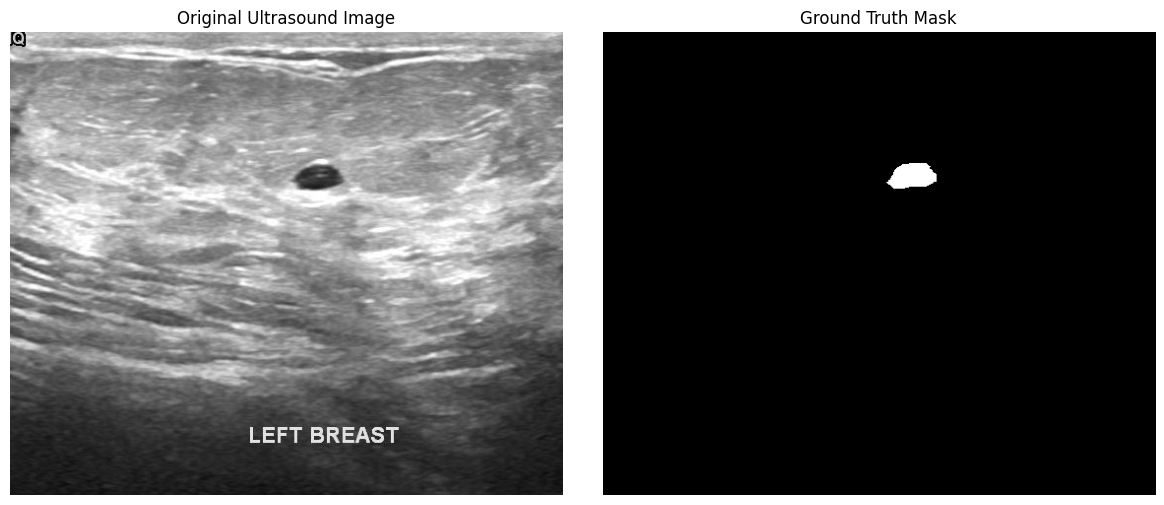

In [8]:
# ============================================================
# 09. 同时显示原始超声图和医生标注Mask
# ============================================================

# 创建画布
plt.figure(figsize=(12, 5))


# -------------------------------
# 左图：原始超声图
# -------------------------------

plt.subplot(1, 2, 1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Original Ultrasound Image")

plt.axis("off")


# -------------------------------
# 右图：Ground Truth Mask
# -------------------------------

plt.subplot(1, 2, 2)

plt.imshow(
    mask,
    cmap="gray"
)

plt.title("Ground Truth Mask")

plt.axis("off")


# 自动整理布局
plt.tight_layout()

plt.show()

# 最重要的可视化---overlay

In [9]:
# ============================================================
# 10. 把Mask转换成0/1二值Mask
# ============================================================

# mask > 0：
#
# 如果像素 > 0
# 就得到 True
#
# 如果像素 = 0
# 就得到 False
#
# astype(np.uint8)：
# 把True/False转换为：
#
# True  -> 1
# False -> 0
#
binary_mask = (mask > 0).astype(np.uint8)


print("二值化Mask的唯一值:")
print(np.unique(binary_mask))

二值化Mask的唯一值:
[0 1]


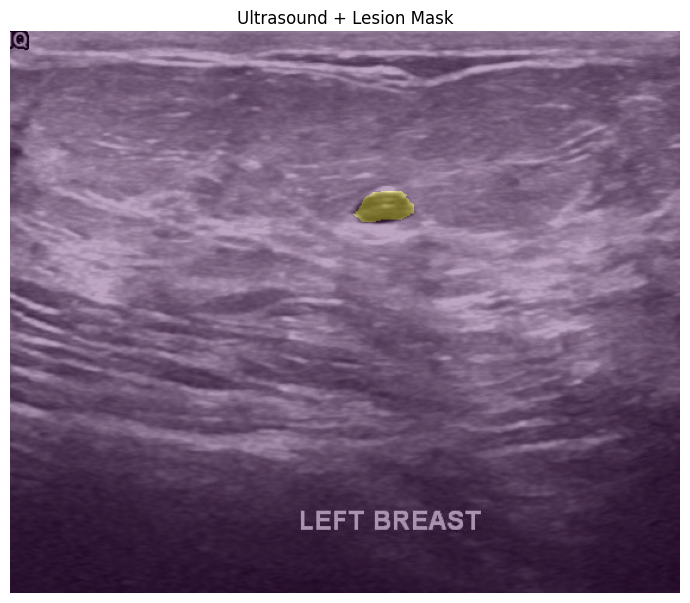

In [ ]:
# ============================================================
# 11. 将病灶Mask叠加到原始超声图上
#分割问题其实是对每一个像素点进行分类
# ============================================================

plt.figure(figsize=(7, 7))


# 第一层：
# 显示原始超声图
plt.imshow(
    image,
    cmap="gray"
)


# 第二层：
# 把Mask覆盖在原图上
#
# alpha=0.35：
# 设置Mask透明度
#
# alpha越小，Mask越透明
#
plt.imshow(
    binary_mask,
    alpha=0.35
)


plt.title("Ultrasound + Lesion Mask")

plt.axis("off")


# 保存图像之前先整理布局
plt.tight_layout()


# 把结果保存到outputs文件夹
plt.savefig(
    "../outputs/data_samples/day01_mask_overlay.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

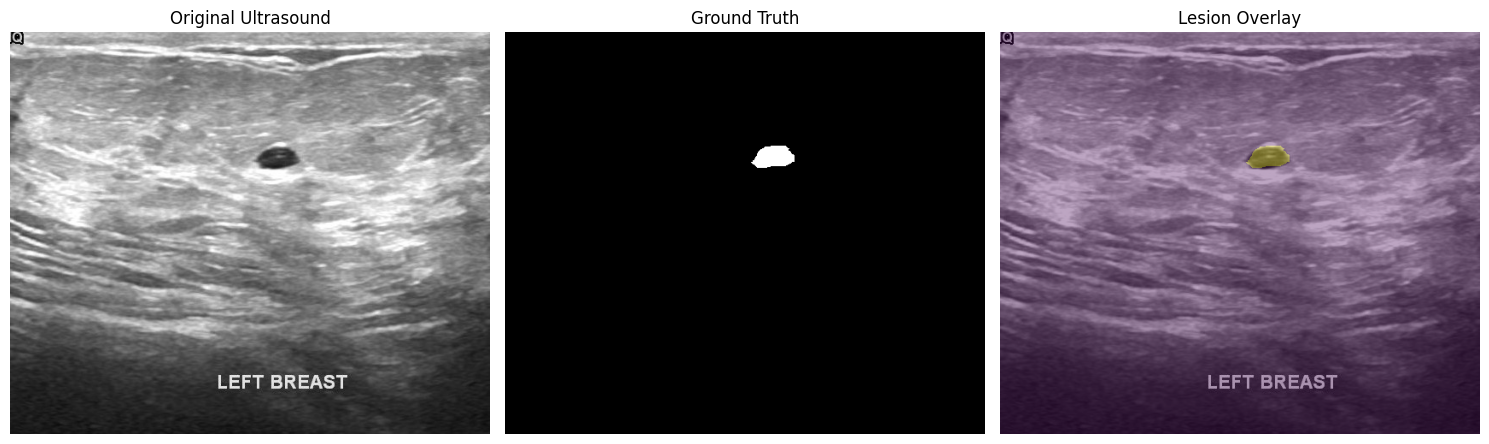

In [12]:
# ============================================================
# 12. 创建项目展示三联图
# ============================================================

plt.figure(figsize=(15, 5))


# -------------------------------
# 1. Original Image
# -------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Original Ultrasound")

plt.axis("off")


# -------------------------------
# 2. Ground Truth
# -------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    binary_mask,
    cmap="gray"
)

plt.title("Ground Truth")

plt.axis("off")


# -------------------------------
# 3. Overlay
# -------------------------------

plt.subplot(1, 3, 3)

# 先画原始超声图
plt.imshow(
    image,
    cmap="gray"
)

# 再覆盖Mask
plt.imshow(
    binary_mask,
    alpha=0.35
)

plt.title("Lesion Overlay")

plt.axis("off")


# 调整图像之间的布局
plt.tight_layout()


# 保存成果图
plt.savefig(
    "../outputs/data_samples/day01_dataset_example.png",
    dpi=300,
    bbox_inches="tight"
)


# 最后显示
plt.show()

## 数据质检---建立数据清单

In [13]:
# ============================================================
# 01. 设置 BUSI 数据集根目录
# ============================================================

# 当前 notebook 位于：
# notebooks/01_data_exploration.ipynb
#
# 所以 ".." 表示先回到项目根目录
#
# 然后进入 data/Dataset_BUSI_with_GT
dataset_root = "../data/Dataset_BUSI_with_GT"


# 我们当前只做“病灶分割”
# 因此只使用 benign 和 malignant 两类
classes = [
    "benign",
    "malignant"
]


print("数据集路径:", dataset_root)

for class_name in classes:
    class_dir = os.path.join(
        dataset_root,
        class_name
    )

    print(
        class_name,
        "文件夹是否存在:",
        os.path.exists(class_dir)
    )

数据集路径: ../data/Dataset_BUSI_with_GT
benign 文件夹是否存在: True
malignant 文件夹是否存在: True


In [14]:
# ============================================================
# 02. 定义函数：根据原图路径寻找对应的所有 Mask
# ============================================================

def find_mask_paths(image_path):
    """
    根据一张原始超声图像的路径，
    自动寻找与它对应的所有 mask 文件。

    参数
    ----------
    image_path : str
        原始超声图路径

    返回
    ----------
    mask_paths : list
        与这张图对应的所有 mask 路径
    """

    # --------------------------------------------------------
    # os.path.splitext()
    # 把：
    #
    # benign (1).png
    #
    # 拆成：
    #
    # benign (1)
    # .png
    # --------------------------------------------------------
    image_stem, image_ext = os.path.splitext(image_path)


    # --------------------------------------------------------
    # 构造搜索模式
    #
    # 例如原图：
    #
    # benign (4).png
    #
    # 我们搜索：
    #
    # benign (4)_mask*.png
    #
    # 这样既可以匹配：
    #
    # benign (4)_mask.png
    #
    # 也可以匹配：
    #
    # benign (4)_mask_1.png
    # benign (4)_mask_2.png
    # --------------------------------------------------------
    mask_pattern = (
        image_stem
        + "_mask*"
        + image_ext
    )


    # glob.glob()
    # 搜索所有符合规则的文件
    mask_paths = glob.glob(mask_pattern)


    # 排序，保证每次读取顺序一致
    mask_paths = sorted(mask_paths)


    return mask_paths

In [ ]:
# ============================================================
# 03. 定义函数：读取并合并多个 Mask，将一个原始图像的多个mask合并成一张图像
# ============================================================

def load_merged_mask(mask_paths):
    """
    读取一张图对应的所有 mask，
    并把它们合并成一个二值 mask。

    合并规则：
    只要某个像素在任意一个 mask 中属于病灶，
    最终合并结果中就认为它属于病灶。
    """

    # 如果根本没有找到 mask
    if len(mask_paths) == 0:
        return None


    merged_mask = None


    # --------------------------------------------------------
    # 依次读取所有 mask
    # --------------------------------------------------------
    for mask_path in mask_paths:

        # 以灰度图形式读取
        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )


        # 如果读取失败
        if mask is None:
            continue


        # ----------------------------------------------------
        # 把原始 mask 转成真正的二值 mask
        #
        # 原始可能是：
        # 0 / 255
        #
        # 转换以后：
        # 0 / 1
        # ----------------------------------------------------
        binary_mask = (
            mask > 0
        ).astype(np.uint8)


        # 第一个 mask
        if merged_mask is None:

            merged_mask = binary_mask.copy()

        else:

            # ----------------------------------------------
            # np.maximum()
            #
            # 相当于做“逻辑或”
            #
            # 例如：
            #
            # Mask A = 0
            # Mask B = 1
            #
            # 最终 = 1
            #
            # 也就是：
            # 任意一个标注认为这里是病灶，
            # 最终就保留下来
            # ----------------------------------------------
            merged_mask = np.maximum(
                merged_mask,
                binary_mask
            )


    return merged_mask

In [16]:
# ============================================================
# 04. 扫描整个数据集，建立数据清单
# ============================================================

# records 用来保存每一张图的信息
#
# 最后我们会把它变成 pandas DataFrame
records = []


# ------------------------------------------------------------
# 遍历两个类别
# ------------------------------------------------------------
for class_name in classes:

    # 当前类别文件夹
    class_dir = os.path.join(
        dataset_root,
        class_name
    )


    # 找到该文件夹所有 png
    all_png_files = glob.glob(
        os.path.join(
            class_dir,
            "*.png"
        )
    )


    # --------------------------------------------------------
    # 排除所有 mask 文件
    #
    # 剩下的才是真正的原始超声图
    # --------------------------------------------------------
    image_files = [
        path
        for path in all_png_files
        if "_mask" not in os.path.basename(path)
    ]


    print(
        f"{class_name}: "
        f"{len(image_files)} 张原始图像"
    )


    # --------------------------------------------------------
    # 逐张检查
    # --------------------------------------------------------
    for image_path in image_files:

        # 读取原始图
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )


        # 如果读图失败
        if image is None:
            print(
                "读取失败:",
                image_path
            )

            continue


        # 图像大小
        height, width = image.shape


        # 找对应的 mask
        mask_paths = find_mask_paths(
            image_path
        )


        # 合并多个 mask
        merged_mask = load_merged_mask(
            mask_paths
        )


        # ----------------------------------------------------
        # 检查是否存在有效 mask
        # ----------------------------------------------------
        if merged_mask is not None:

            has_mask = True

            # 病灶区域像素数量
            lesion_pixels = int(
                merged_mask.sum()
            )

            # 图像总像素数量
            total_pixels = (
                height * width
            )

            # ----------------------------------------------
            # 病灶占整张图片的比例
            #
            # 例如：
            #
            # 0.10
            #
            # 表示病灶大约占10%的图像面积
            # ----------------------------------------------
            lesion_area_ratio = (
                lesion_pixels
                / total_pixels
            )

        else:

            has_mask = False

            lesion_pixels = 0

            lesion_area_ratio = 0


        # ----------------------------------------------------
        # 把当前图片的信息保存起来
        # ----------------------------------------------------
        records.append({

            "class": class_name,

            "image_name":
                os.path.basename(
                    image_path
                ),

            "image_path":
                image_path,

            "height":
                height,

            "width":
                width,

            "num_masks":
                len(mask_paths),

            "has_mask":
                has_mask,

            "lesion_pixels":
                lesion_pixels,

            "lesion_area_ratio":
                lesion_area_ratio
        })

benign: 437 张原始图像
malignant: 210 张原始图像


In [20]:
# ============================================================
# 05. 把 records 转成 Pandas DataFrame
# ============================================================

df = pd.DataFrame(records)


print("数据集总图像数:")
print(len(df))


print("\n前5行:")
display(
    df.head()
)
# ============================================================
# 06. 数据完整性检查
# ============================================================

print("没有找到 Mask 的图像数量:")

print(
    (~df["has_mask"]).sum()
)

数据集总图像数:
647

前5行:


,class,image_name,image_path,height,width,num_masks,has_mask,lesion_pixels,lesion_area_ratio
0,benign,benign (1).png,../data/Dataset_BUSI_with_GT\benign\benign (1)...,471,562,1,True,984,0.003717
1,benign,benign (10).png,../data/Dataset_BUSI_with_GT\benign\benign (10...,585,683,1,True,32918,0.082387
2,benign,benign (100).png,../data/Dataset_BUSI_with_GT\benign\benign (10...,473,323,2,True,10011,0.065526
3,benign,benign (101).png,../data/Dataset_BUSI_with_GT\benign\benign (10...,473,563,1,True,4167,0.015648
4,benign,benign (102).png,../data/Dataset_BUSI_with_GT\benign\benign (10...,610,634,1,True,18857,0.048759


没有找到 Mask 的图像数量:
0


In [21]:
# ============================================================
# 07. 查看类别分布
# ============================================================

class_counts = (
    df["class"]
    .value_counts()
)

print(class_counts)

class
benign       437
malignant    210
Name: count, dtype: int64


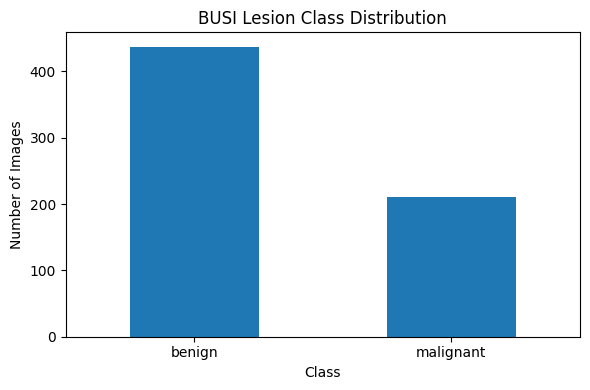

In [ ]:
# ============================================================
# 08. 可视化类别分布
#为什么要看类别分布？
#因为机器学习里有一个很重要的问题是class imbalance
#目前的话因为benign所占的比例比较高，模型可能学会，全部猜benign
# ============================================================

plt.figure(figsize=(6, 4))


class_counts.plot(
    kind="bar"
)


plt.title(
    "BUSI Lesion Class Distribution"
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Images"
)

plt.xticks(
    rotation=0
)


plt.tight_layout()

plt.savefig(
    "../outputs/data_samples/day01_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# 09. 查看不同图像尺寸，判断尺寸是否统一---后边resize
# ============================================================

size_counts = (
    df
    .groupby(
        ["height", "width"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)


print("不同尺寸组合数量:")

print(
    len(size_counts)
)


display(
    size_counts.head(10)  #只展示前10名
)

####
# ============================================================
# 09. 查看不同图像尺寸，判断尺寸是否统一---后边resize
# ============================================================

size_counts = (
    df
    .groupby(
        ["height", "width"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)


print("不同尺寸组合数量:")

print(
    len(size_counts)
)


display(
    size_counts.head(10)  #只展示前10名
)

#================================================
#不同尺寸组合数量：545，说明数据集图像尺寸非常不统一
#后面需要做resize
#================================================



不同尺寸组合数量:
545


,height,width,count
157,465,557,6
208,469,564,4
133,463,556,3
35,390,465,3
235,471,555,3
183,468,555,3
224,470,562,3
33,389,473,3
144,464,556,3
488,587,775,3


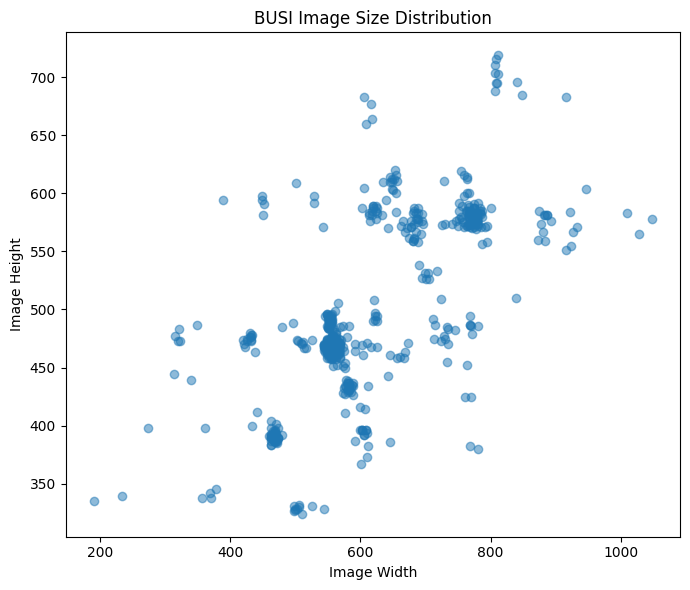

In [24]:
# ============================================================
# 10. 可视化图像尺寸分布
# ============================================================

plt.figure(figsize=(7, 6))


plt.scatter(
    df["width"],
    df["height"],
    alpha=0.5
)


plt.xlabel(
    "Image Width"
)

plt.ylabel(
    "Image Height"
)

plt.title(
    "BUSI Image Size Distribution"
)


plt.tight_layout()


plt.savefig(
    "../outputs/data_samples/day01_image_size_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [25]:
# ============================================================
# 11. 随机抽取6个病例
# ============================================================

# random_state=42
# 保证每次运行抽到的样本一样
#
# 这样方便复现实验
sample_df = df.sample(
    n=6,
    random_state=42
)


display(
    sample_df[
        [
            "class",
            "image_name",
            "height",
            "width"
        ]
    ]
)

,class,image_name,height,width
634,malignant,malignant (88).png,591,775
220,benign,benign (298).png,391,466
426,benign,benign (9).png,585,752
428,benign,benign (91).png,704,806
72,benign,benign (164).png,470,560
437,malignant,malignant (1).png,598,449


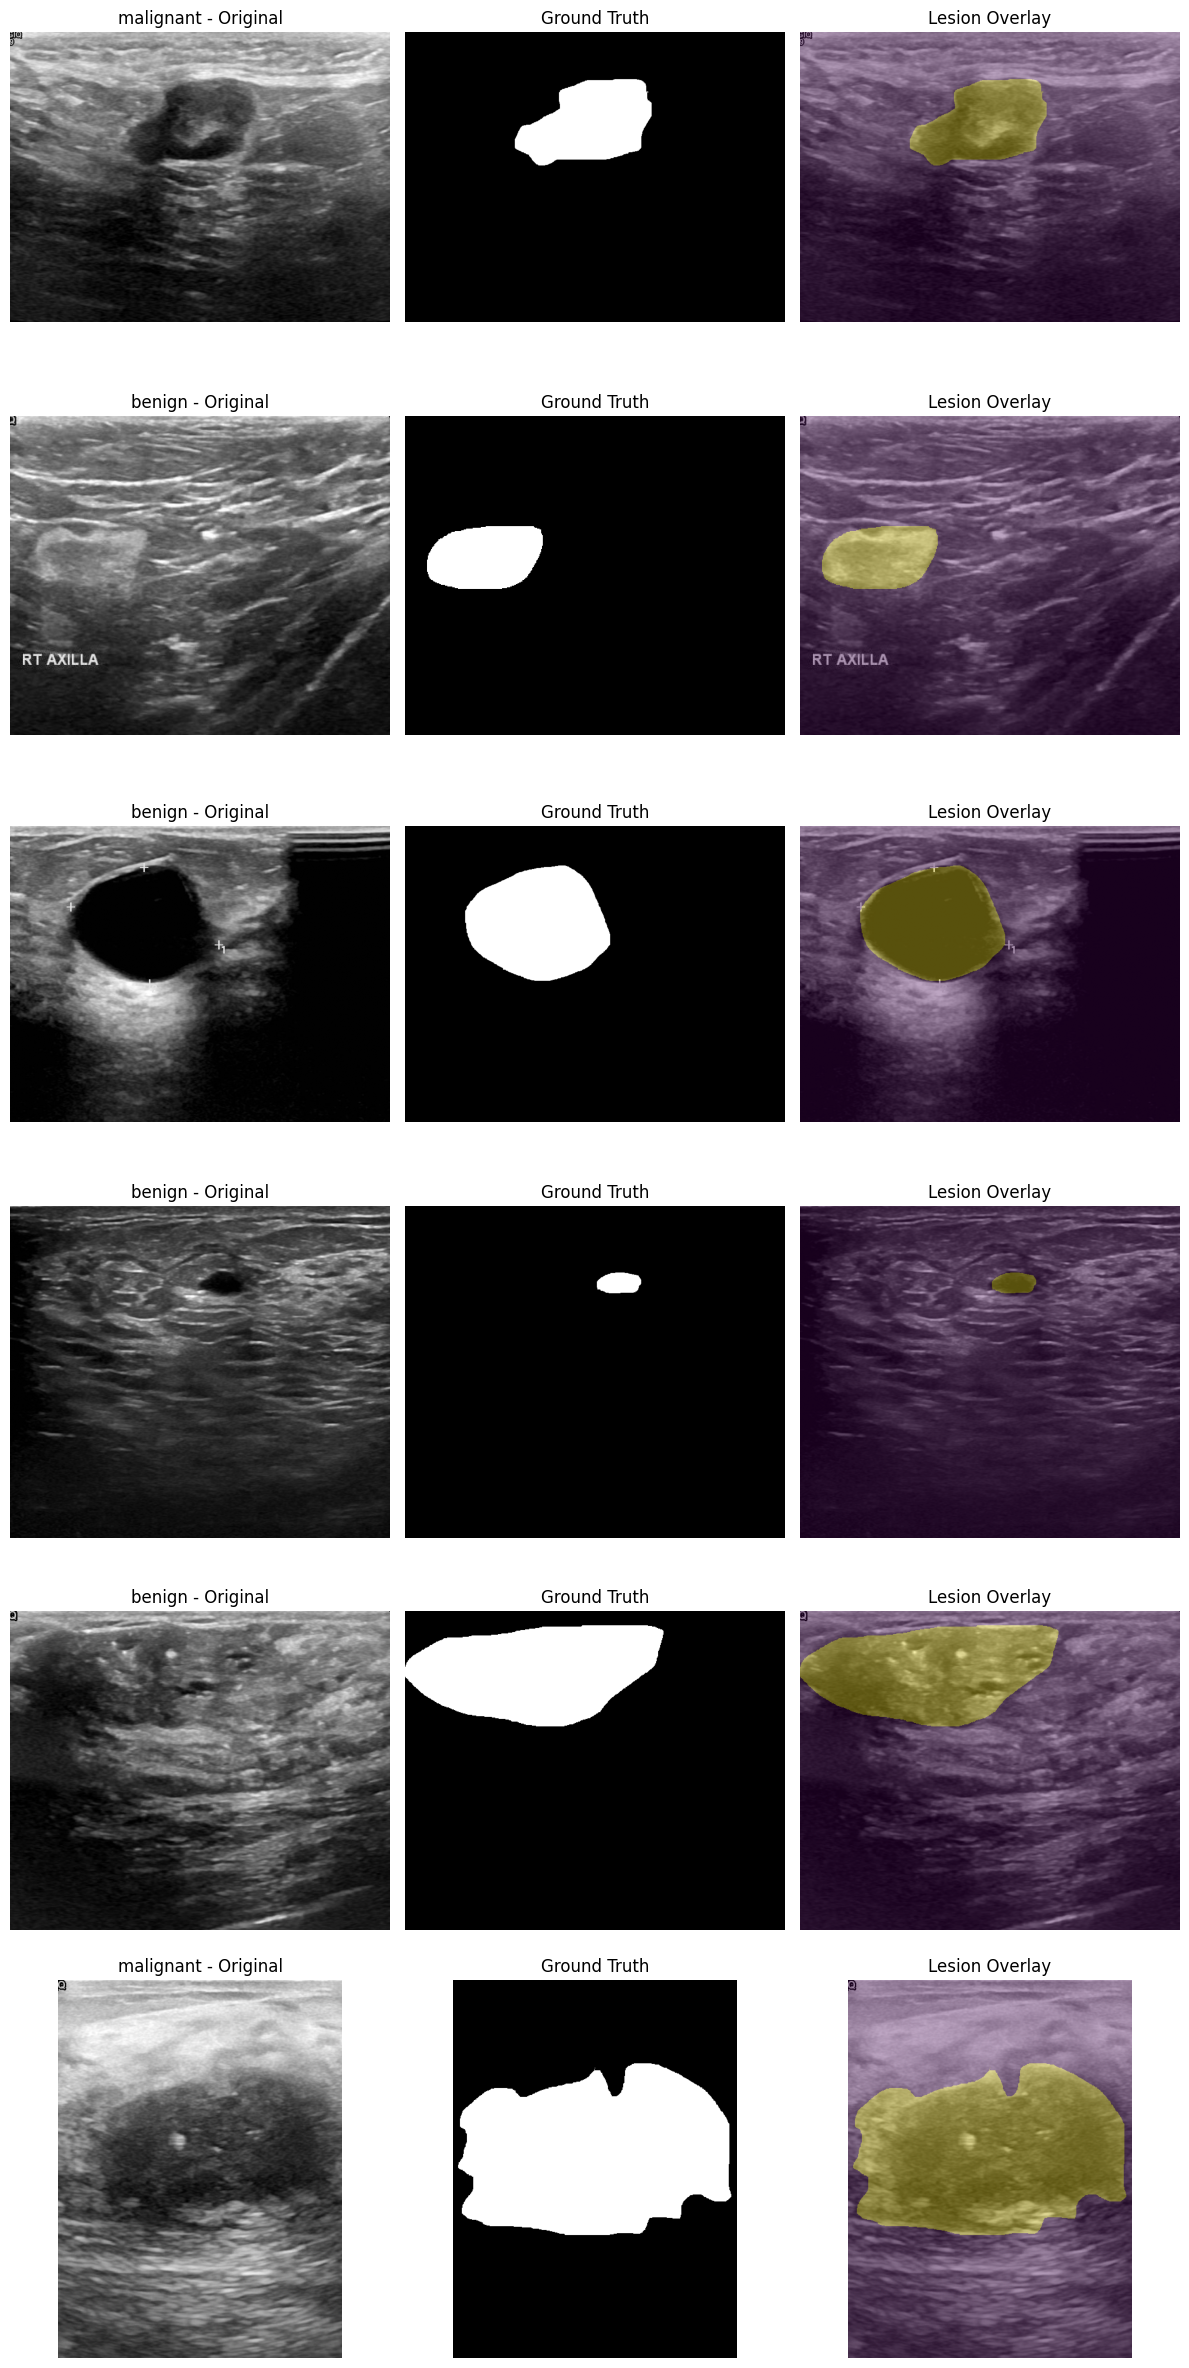

In [26]:
# ============================================================
# 12. 可视化6个随机病例
# ============================================================

# 6行 × 3列
fig, axes = plt.subplots(
    6,
    3,
    figsize=(12, 24)
)


# ------------------------------------------------------------
# 遍历抽到的6个病例
# ------------------------------------------------------------
for row_idx, (_, row) in enumerate(
    sample_df.iterrows()
):

    # 原始图路径
    image_path = row[
        "image_path"
    ]


    # 读取原始超声图
    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )


    # 找mask
    mask_paths = find_mask_paths(
        image_path
    )


    # 合并mask
    mask = load_merged_mask(
        mask_paths
    )


    # ========================================================
    # 第一列：原始超声图
    # ========================================================

    axes[row_idx, 0].imshow(
        image,
        cmap="gray"
    )

    axes[row_idx, 0].set_title(
        f"{row['class']} - Original"
    )

    axes[row_idx, 0].axis(
        "off"
    )


    # ========================================================
    # 第二列：Ground Truth
    # ========================================================

    axes[row_idx, 1].imshow(
        mask,
        cmap="gray"
    )

    axes[row_idx, 1].set_title(
        "Ground Truth"
    )

    axes[row_idx, 1].axis(
        "off"
    )


    # ========================================================
    # 第三列：Overlay
    # ========================================================

    # 先画超声图
    axes[row_idx, 2].imshow(
        image,
        cmap="gray"
    )


    # 再把mask覆盖上去
    axes[row_idx, 2].imshow(
        mask,
        alpha=0.35
    )


    axes[row_idx, 2].set_title(
        "Lesion Overlay"
    )

    axes[row_idx, 2].axis(
        "off"
    )


# 自动调整间距
plt.tight_layout()


# 保存项目成果
plt.savefig(
    "../outputs/data_samples/day01_random_samples.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

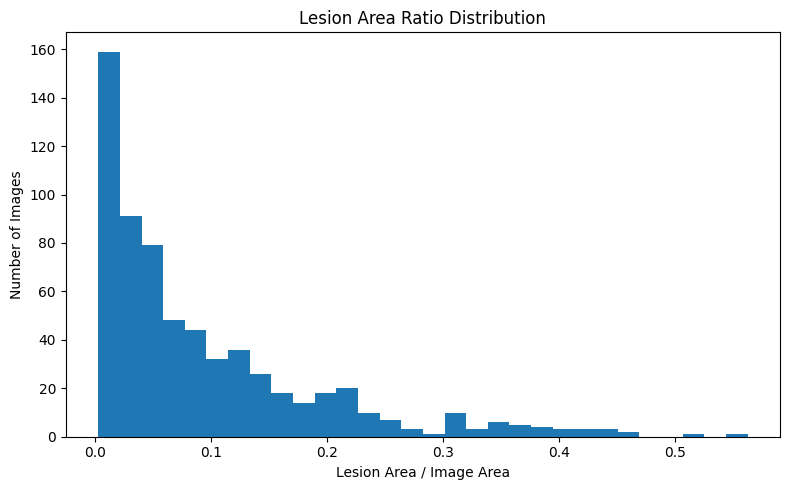

In [ ]:
# ============================================================
# 13. 病灶面积比例分布
# ============================================================

plt.figure(figsize=(8, 5))


plt.hist(
    df["lesion_area_ratio"],
    bins=30
)


plt.xlabel(
    "Lesion Area / Image Area"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Lesion Area Ratio Distribution"
)


plt.tight_layout()


plt.savefig(
    "../outputs/data_samples/day01_lesion_area_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


#====================================
#像素级别不平衡的问题：
#从你这张图看，分布明显右偏，很多图像的病灶面积占比都在 10%以下，相当一部分可能只有几个百分点。也就是说，一张图里绝大多数像素都是 background。
#就算模型什么都不学，把所有的像素都定为背景，准确率也会很高，所以要结合其他的指标一块来看
#====================================


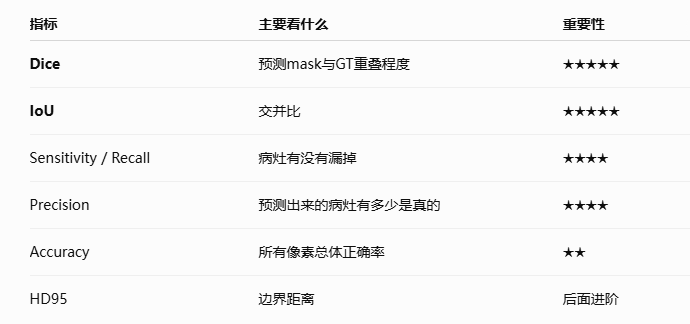
#### Observation

The lesion area ratio shows a strongly right-skewed distribution.
Most lesions occupy only a small fraction of the full ultrasound image,
indicating substantial foreground-background pixel imbalance.

Therefore, pixel accuracy may be misleading because a model predicting
mostly background pixels can still achieve high accuracy.

For segmentation evaluation, Dice score and IoU will be used as the
primary metrics. BCE + Dice loss will be considered during model training
to alleviate foreground-background imbalance.

问题1：我们目前做的只是分割任务，不是分类任务，暂时不能通过分出来的病灶区分是良性的还是恶性的；这部分可以作为下一个阶段的任务，，对比传统的机器学习和深度学习的效果

问题2：判断肿瘤区域的时候，，医生不只是看这团黑不黑，明显不明显，会综合看形态学和声学特征：
形状：oval / round / irregular
方向：是否平行于皮肤，还是“纵向长得更深”
边界：circumscribed 还是 indistinct / angular / microlobulated / spiculated
内部回声：均匀还是不均匀
后方声学特征：增强、衰减、阴影
周围组织改变：结构扭曲、皮肤/导管变化
还可能结合血流、弹性成像等信息。ACR 的 BI-RADS 超声体系就是围绕这些特征组织判断的。
恶性真正可疑的地方，可能不只是对比度，而是：边界不规则、不平行生长、毛刺、周围结构被拉扯、内部回声异质、后方声影


In [29]:
# ============================================================
# 14. 保存整个数据集的质检结果
# ============================================================

output_csv = (
    "../outputs/"
    "dataset_summary.csv"
)


df.to_csv(
    output_csv,

    # 不保存Pandas自动生成的行号
    index=False,

    # 防止中文乱码
    encoding="utf-8-sig"
)


print(
    "数据质检表已保存:"
)

print(
    output_csv
)

数据质检表已保存:
../outputs/dataset_summary.csv


In [30]:
# ============================================================
# 15. Day 1 数据集总结
# ============================================================

print(
    "========== BUSI Dataset Summary =========="
)

print(
    f"Total lesion images: {len(df)}"
)


print(
    "\nClass distribution:"
)

print(
    df["class"].value_counts()
)


print(
    "\nMissing masks:",
    (~df["has_mask"]).sum()
)


print(
    "\nImage height:"
)

print(
    df["height"].describe()
)


print(
    "\nImage width:"
)

print(
    df["width"].describe()
)


print(
    "\nLesion area ratio:"
)

print(
    df["lesion_area_ratio"].describe()
)

========== BUSI Dataset Summary ==========
Total lesion images: 647

Class distribution:
class
benign       437
malignant    210
Name: count, dtype: int64

Missing masks: 0

Image height:
count    647.000000
mean     494.998454
std       72.823390
min      324.000000
25%      463.000000
50%      472.000000
75%      572.000000
max      719.000000
Name: height, dtype: float64

Image width:
count     647.000000
mean      608.383308
std       120.021031
min       190.000000
25%       554.000000
50%       564.000000
75%       686.000000
max      1048.000000
Name: width, dtype: float64

Lesion area ratio:
count    647.000000
mean       0.094354
std        0.098776
min        0.002812
25%        0.022401
50%        0.057643
75%        0.130898
max        0.562924
Name: lesion_area_ratio, dtype: float64


In [31]:
print(df.columns.tolist())
print(df.head())

['class', 'image_name', 'image_path', 'height', 'width', 'num_masks', 'has_mask', 'lesion_pixels', 'lesion_area_ratio']
    class        image_name  \
0  benign    benign (1).png   
1  benign   benign (10).png   
2  benign  benign (100).png   
3  benign  benign (101).png   
4  benign  benign (102).png   

                                          image_path  height  width  \
0  ../data/Dataset_BUSI_with_GT\benign\benign (1)...     471    562   
1  ../data/Dataset_BUSI_with_GT\benign\benign (10...     585    683   
2  ../data/Dataset_BUSI_with_GT\benign\benign (10...     473    323   
3  ../data/Dataset_BUSI_with_GT\benign\benign (10...     473    563   
4  ../data/Dataset_BUSI_with_GT\benign\benign (10...     610    634   

   num_masks  has_mask  lesion_pixels  lesion_area_ratio  
0          1      True            984           0.003717  
1          1      True          32918           0.082387  
2          2      True          10011           0.065526  
3          1      True        

In [ ]:
import pandas as pd

# ==============================
# 1. 根据病灶面积比例划分病灶大小
#后边我们需要根据病理类比和病灶大小建立“联合分层标签”
# ==============================

# pd.qcut：
# 按照数据的分位数进行划分。
#
# q=3 表示把全部样本尽量平均分成三组：
#   前 1/3       -> small
#   中间 1/3     -> medium
#   后 1/3       -> large
#
# 注意：
# 这里不是根据医学标准定义“小病灶/大病灶”，
# 只是为了让 train/val/test 中的病灶大小分布尽量一致。

df["size_group"] = pd.qcut(
    df["lesion_area_ratio"],
    q=3,
    labels=["small", "medium", "large"]
)

# 查看每组有多少张图
print(df["size_group"].value_counts())

# 查看每组对应的病灶面积范围
print(
    df.groupby("size_group", observed=True)["lesion_area_ratio"]
      .agg(["min", "median", "max"])
)

size_group
small     216
large     216
medium    215
Name: count, dtype: int64
                 min    median       max
size_group                              
small       0.002812  0.014537  0.031667
medium      0.031749  0.057643  0.102591
large       0.104480  0.179393  0.562924


In [ ]:
# ==================================
# 2. 建立联合分层标签
#这样划分比单纯随机划分规范得多
# ==================================

# 举例：
#
# benign_small
# benign_medium
# benign_large
# malignant_small
# malignant_medium
# malignant_large
#
# 后面 train_test_split 会尽量保证
# 这 6 类样本在三个数据集中比例接近。

df["stratify_group"] = (
    df["class"].astype(str)
    + "_"
    + df["size_group"].astype(str)
)

print(df["stratify_group"].value_counts())

stratify_group
benign_small        202
benign_medium       139
malignant_large     120
benign_large         96
malignant_medium     76
malignant_small      14
Name: count, dtype: int64


In [34]:
import sklearn
from sklearn.model_selection import train_test_split

# ==========================================================
# 3. 第一次划分：
#    70% train
#    30% temp
#
# temp 后面再平均分成 val 和 test
# ==========================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,                  # 30% 暂时拿出来
    random_state=42,                 # 固定随机种子，保证每次结果一致
    stratify=df["stratify_group"]    # 按联合标签分层
)


# ==========================================================
# 4. 第二次划分：
#    temp 里面再 50% / 50%
#
# 因为 temp 占总数据 30%
#
# 所以：
# 30% × 50% = 15%
#
# 最终得到：
# train = 70%
# val   = 15%
# test  = 15%
# ==========================================================

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_group"]
)


# 重置 DataFrame 的行号
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)


print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 452
Val: 97
Test: 98


In [35]:
# ==========================================================
# 5. 检查三个数据集的类别分布
# ==========================================================

def show_split_info(name, data):

    print(f"\n========== {name} ==========")

    print("Number of images:")
    print(len(data))

    print("\nClass distribution:")
    print(
        data["class"]
        .value_counts(normalize=True)
        .round(3)
    )

    print("\nLesion size distribution:")
    print(
        data["size_group"]
        .value_counts(normalize=True)
        .sort_index()
        .round(3)
    )

    print("\nMean lesion area ratio:")
    print(
        round(data["lesion_area_ratio"].mean(), 4)
    )


show_split_info("TRAIN", train_df)
show_split_info("VAL", val_df)
show_split_info("TEST", test_df)


========== TRAIN ==========
Number of images:
452

Class distribution:
class
benign       0.675
malignant    0.325
Name: proportion, dtype: float64

Lesion size distribution:
size_group
small     0.334
medium    0.332
large     0.334
Name: proportion, dtype: float64

Mean lesion area ratio:
0.0968

========== VAL ==========
Number of images:
97

Class distribution:
class
benign       0.67
malignant    0.33
Name: proportion, dtype: float64

Lesion size distribution:
size_group
small     0.33
medium    0.34
large     0.33
Name: proportion, dtype: float64

Mean lesion area ratio:
0.0917

========== TEST ==========
Number of images:
98

Class distribution:
class
benign       0.684
malignant    0.316
Name: proportion, dtype: float64

Lesion size distribution:
size_group
small     0.337
medium    0.327
large     0.337
Name: proportion, dtype: float64

Mean lesion area ratio:
0.0859


In [36]:
from pathlib import Path

# ========================================
# 6. 保存数据划分
#后边为了对比不同的模型，需要固定数据集的划分
# ========================================

split_dir = Path("../data/splits")

# 如果文件夹不存在，就自动创建
split_dir.mkdir(
    parents=True,
    exist_ok=True
)

train_df.to_csv(
    split_dir / "train.csv",
    index=False
)

val_df.to_csv(
    split_dir / "val.csv",
    index=False
)

test_df.to_csv(
    split_dir / "test.csv",
    index=False
)

print("Dataset splits saved successfully!")

Dataset splits saved successfully!


## 将图像使用pytorch转换成张量tensor

#### 新建src/dataset.py
#### 测试dataset  dataset解决的是一张数据应该怎么处理；而DataLoader解决的问题是训练的时候怎么一批一批地那数据送给模型

In [1]:
import sys
from pathlib import Path

# 将项目根目录加入 Python 搜索路径
project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.dataset import BUSIDataset

#创建训练集
train_dataset = BUSIDataset(
    csv_file="../data/splits/train.csv",
    image_size=(256, 256)
)
print("Dataset length:", len(train_dataset))

Loaded dataset: 452 images
Dataset length: 452


In [5]:
#把训练集的第一个样本拿出来
import torch
sample = train_dataset[0]
image = sample["image"]
mask = sample["mask"]

print(
    "Image shape:",
    sample["image"].shape
)

print(
    "Mask shape:",
    sample["mask"].shape
)

print(
    "Image range:",
    sample["image"].min().item(),
    sample["image"].max().item()
)

print(
    "Mask unique values:",
    torch.unique(sample["mask"])
)

print(
    "Number of masks:",
    sample["num_masks"]
)

Image shape: torch.Size([1, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Image range: 0.0 0.8705882430076599
Mask unique values: tensor([0., 1.])
Number of masks: 1


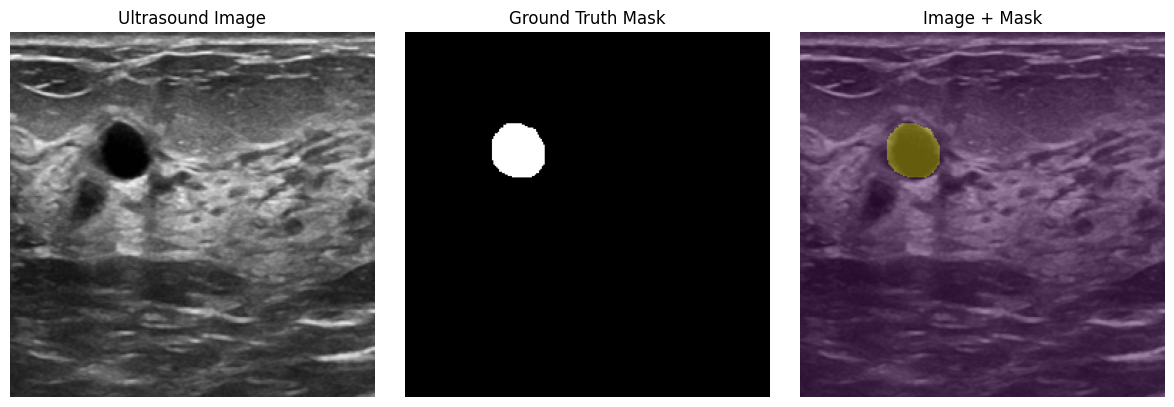

In [6]:
import matplotlib.pyplot as plt


image_np = image.squeeze(0).numpy()
mask_np = mask.squeeze(0).numpy()


plt.figure(figsize=(12, 4))


# -------------------------
# 原始超声图
# -------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    image_np,
    cmap="gray"
)

plt.title("Ultrasound Image")

plt.axis("off")


# -------------------------
# Ground Truth Mask
# -------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    mask_np,
    cmap="gray"
)

plt.title("Ground Truth Mask")

plt.axis("off")


# -------------------------
# Overlay
# -------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    image_np,
    cmap="gray"
)

plt.imshow(
    mask_np,
    alpha=0.4
)

plt.title("Image + Mask")

plt.axis("off")


plt.tight_layout()

plt.show()

In [7]:
from torch.utils.data import DataLoader


train_loader = DataLoader(
    train_dataset,

    # 一次取 8 张图片
    batch_size=8,

    # 每个 epoch 都重新打乱训练数据
    shuffle=True,

    # 暂时使用主进程读取数据
    # Windows + Jupyter 下这样最稳
    num_workers=0
)

In [8]:
batch = next(iter(train_loader))

images = batch["image"]
masks = batch["mask"]

print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)

Batch image shape: torch.Size([8, 1, 256, 256])
Batch mask shape: torch.Size([8, 1, 256, 256])
